In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import networkx as nx
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

# --- 解析パラメータ ---
DEFAULT_DILATE_PX = 3000
DEFAULT_HEIGHT_RATIO = 0.4  # 歪み補正の強度（0.3~0.7）
STRUCTURAL_AREA_RATIO = 1.1 # 平均面積の何倍以上を「構造石」とみなすか

# --- 一括管理するパス ---
image_path = "images/test_ishigaki_resized.jpg" 
checkpoint_path = "sam_vit_b_01ec64.pth" 

In [8]:
# ==========================================
#       SAM関連 & 基本関数
# ==========================================

def show_anns(anns):
    if len(anns) == 0: return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def process_with_sam(image_path, model_checkpoint):
    print("--- SAM解析開始 ---")
    image = cv2.imread(image_path)
    if image is None:
        print(f"エラー: 画像が見つかりません: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_type = "vit_b"
    sam = sam_model_registry[model_type](checkpoint=model_checkpoint)
    sam.to(device=device)

    mask_generator = SamAutomaticMaskGenerator(
        model=sam,
        points_per_side=64,  
        pred_iou_thresh=0.92,         
        stability_score_thresh=0.96,  
        min_mask_region_area=3000,   
        crop_n_layers=0,
    )
    masks = mask_generator.generate(image)
    print(f"検出された石（領域）の数: {len(masks)}")
    return masks

def sort_masks_bottom_up(masks):
    return sorted(masks, key=lambda x: x['bbox'][1], reverse=True)

def visualize_labeled_masks(image, masks, title="Labeled Stones"):
    vis_img = image.copy()
    overlay = vis_img.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    for i, mask in enumerate(masks):
        idx = i + 1
        y_indices, x_indices = np.where(mask['segmentation'])
        if len(y_indices) == 0: continue
        center_y = int(np.mean(y_indices))
        center_x = int(np.mean(x_indices))
        color = np.random.randint(0, 255, (3,)).tolist()
        overlay[mask['segmentation']] = color
        text = str(idx)
        cv2.putText(vis_img, text, (center_x-10, center_y+10), font, 0.7, (255, 255, 255), 2)
    cv2.addWeighted(overlay, 0.4, vis_img, 0.6, 0, vis_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

def main():
    masks = process_with_sam(image_path, checkpoint_path)
    if masks is None: return None, None
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    current_masks = sort_masks_bottom_up(masks)
    
    while True:
        visualize_labeled_masks(image_rgb, current_masks, title=f"Check: {len(current_masks)} stones")
        print("【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。")
        user_input = input("削除番号 >> ")
        if not user_input.strip(): break
        try:
            remove_ids = set(map(int, user_input.split()))
            new_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
            current_masks = new_masks
            if len(current_masks) == 0: break
        except ValueError: print("数値を入力してください。")

    print("データフレームを作成中...")
    data_list = []
    for i, m in enumerate(current_masks):
        x, y, w, h = m['bbox']
        cx, cy = x + w / 2, y + h / 2
        data_list.append({'Stone_ID': i + 1, 'Area': m['area'], 'bbox': m['bbox'], 'Centroid_X': cx, 'Centroid_Y': cy})
    df = pd.DataFrame(data_list)
    print("メイン処理完了。")
    return current_masks, df

# ==========================================
#       段推定関数 (構造石判定 + 歪み補正)
# ==========================================

def apply_dynamic_tiering_v5(masks, df_stones, height_ratio=DEFAULT_HEIGHT_RATIO, dilate_px=DEFAULT_DILATE_PX):
    """
    動的閾値による段推定を行い、かつ構造石(is_structural)の判定も行う
    """
    print(f"\n--- 動的ティアリング解析 (歪み補正: Ratio={height_ratio}) ---")
    df_work = df_stones.copy()
    print(f"総石数: {len(df_work)}")

    # 1. 構造石の特定（描画で使うためここで計算）
    avg_area = df_work['Area'].mean()
    df_work['is_structural'] = df_work['Area'] > (avg_area * STRUCTURAL_AREA_RATIO)
    print(f"構造石の数: {df_work['is_structural'].sum()}")

    # 2. 段推定の準備
    df_work['Tier'] = -1
    df_work['mask_index'] = df_stones.index 
    df_work = df_work.sort_values('Centroid_Y', ascending=False)
    processed_indices = set()
    current_tier = 1
    
    dilated_masks_cache = {}
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for idx in df_work.index:
        m_idx = int(df_work.loc[idx, 'mask_index'])
        dilated_masks_cache[idx] = cv2.dilate(masks[m_idx]['segmentation'].astype(np.uint8), kernel, iterations=1)

    # 3. ボトムアップ探索
    for i in range(len(df_work)):
        target_idx = df_work.index[i]
        if target_idx in processed_indices: continue
            
        queue = [target_idx]
        processed_indices.add(target_idx)
        df_work.at[target_idx, 'Tier'] = current_tier
        
        q_idx = 0
        while q_idx < len(queue):
            curr_idx = queue[q_idx]
            q_idx += 1
            curr_row = df_work.loc[curr_idx]
            h_curr = curr_row['bbox'][3]
            
            for other_idx in df_work.index:
                if other_idx == curr_idx: continue
                other_row = df_work.loc[other_idx]
                h_other = other_row['bbox'][3]
                
                # 動的閾値（歪み補正）
                avg_height = (h_curr + h_other) / 2
                dynamic_threshold = avg_height * height_ratio
                
                if abs(curr_row['Centroid_Y'] - other_row['Centroid_Y']) < dynamic_threshold:
                    m_idx_j = int(other_row['mask_index'])
                    if np.any(np.logical_and(dilated_masks_cache[curr_idx], masks[m_idx_j]['segmentation'])):
                        if other_idx not in processed_indices:
                            df_work.at[other_idx, 'Tier'] = current_tier
                            processed_indices.add(other_idx)
                            queue.append(other_idx)
        current_tier += 1
    
    # 4. ティア正規化
    unique_tiers = sorted(df_work['Tier'].unique()) 
    tier_map = {old: new + 1 for new, old in enumerate(unique_tiers)}
    df_work['Tier'] = df_work['Tier'].map(tier_map)
    
    # KDE計算（右図用）
    y_values = df_work['Centroid_Y'].values
    kde = gaussian_kde(y_values, bw_method=0.15)
    y_grid = np.linspace(y_values.min()-50, y_values.max()+50, 1000)
    y_density = kde(y_grid)
    
    return df_work, y_grid, y_density



In [9]:
# ==========================================
#       実行ブロック(前半)
# ==========================================
if __name__ == "__main__":
    current_masks, df = main() 

    if current_masks is not None:
        # 動的ティアリング実行
        df, y_grid, y_density = apply_dynamic_tiering_v5(current_masks, df)
        
        print("\n--- ティア別解析結果 ---")
        print(df['Tier'].value_counts().sort_index(ascending=False))

        # 可視化
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))

        # [左図] 空間プロット 
        ax[0].invert_yaxis() # Y軸反転
        
        # 全石を表示（段ごとに色分け）
        scatter = ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
        
        # 構造石のみ枠線を付けて強調
        if 'is_structural' in df.columns:
            struct_df = df[df['is_structural']]
            ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
        
        ax[0].set_title("Structural Tiering Result (Dynamic Corrected)")
        ax[0].legend()

        # [右図] 密度グラフ
        ax[1].plot(y_density, y_grid, color='blue', label='Vertical Density')
        ax[1].invert_yaxis()
        ax[1].set_title("Density Reference")
        ax[1].set_xlabel("Density")
        ax[1].set_ylabel("Y Coordinate")
        ax[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

--- SAM解析開始 ---
エラー: 画像が見つかりません: images/DJI_0471_resized.JPG


[ WARN:0@155.346] global loadsave.cpp:275 findDecoder imread_('images/DJI_0471_resized.JPG'): can't open/read file: check file path/integrity


--- アノテーション修正を再開します (現在の石数: 42) ---


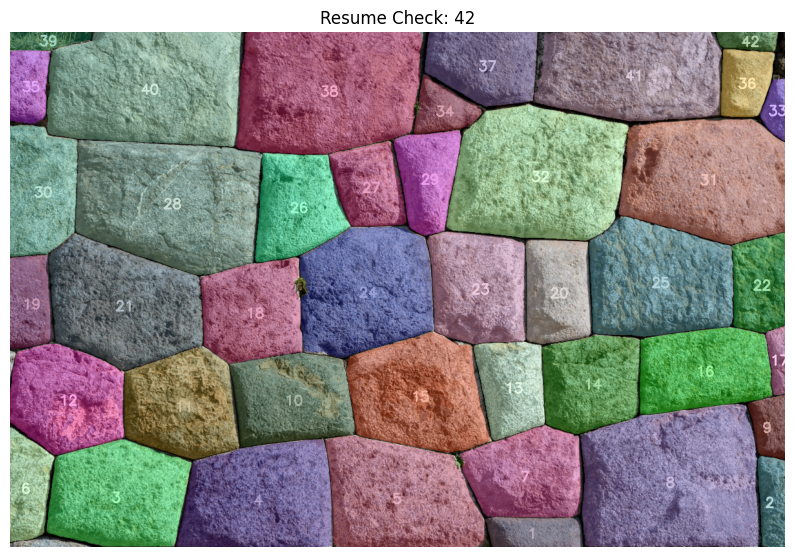

削除したい石の番号を入力 (完了ならEnter)
データベース(df)を再構築中...
動的ティアリング解析を再実行中...

--- 動的ティアリング解析 (歪み補正: Ratio=0.5) ---
総石数: 42
構造石の数: 16

--- 最新の解析結果 ---
Tier
6     2
5     8
4     7
3     8
2    16
1     1
Name: count, dtype: int64


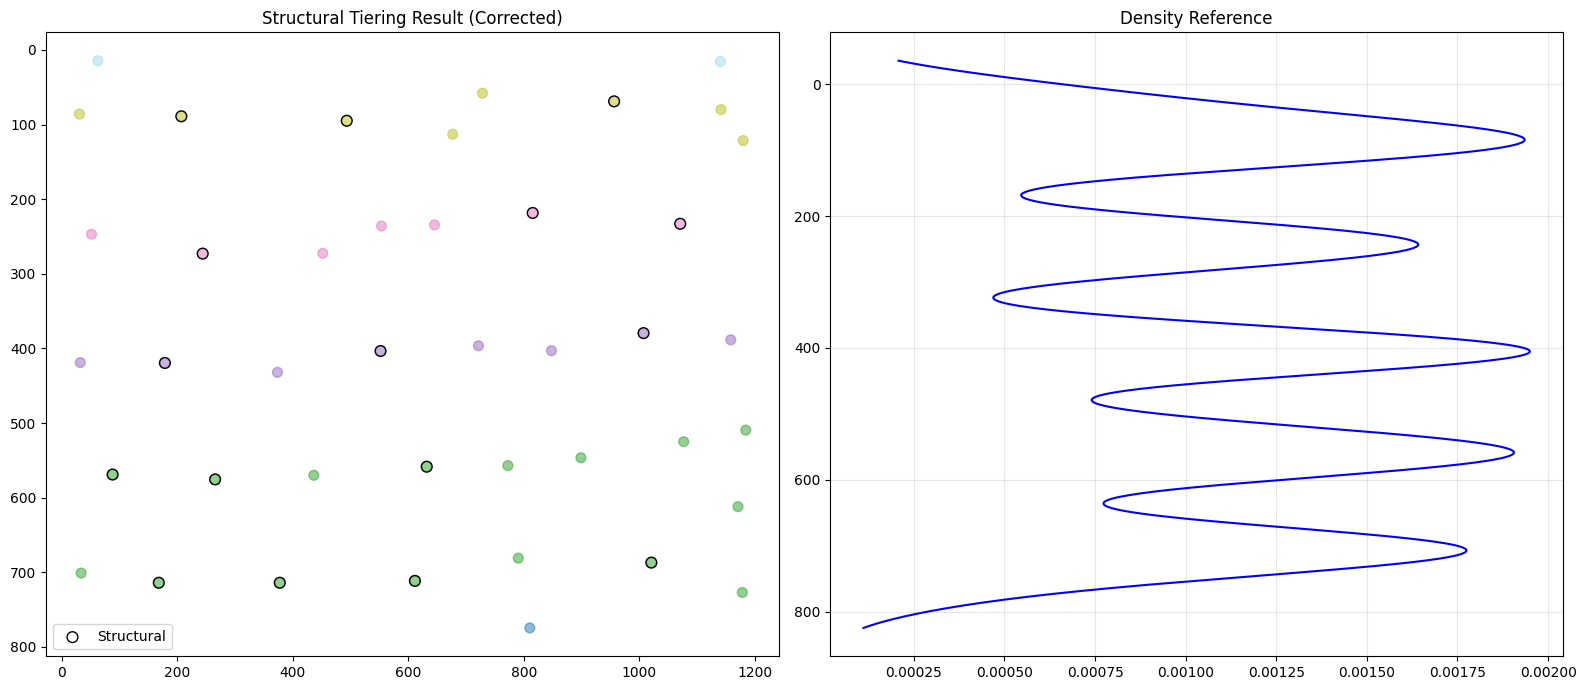

In [65]:
# --- 【必要に応じて】アノテーション再開・データベース更新・再描画ブロック ---
if __name__ == "__main__":
    if 'current_masks' in locals() and current_masks is not None:
        print(f"--- アノテーション修正を再開します (現在の石数: {len(current_masks)}) ---")
        
        # 画像準備
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # --- 修正ループ ---
            while True:
                visualize_labeled_masks(img_rgb, current_masks, title=f"Resume Check: {len(current_masks)}")
                print("削除したい石の番号を入力 (完了ならEnter)")
                user_input = input("削除番号 >> ").strip()
                if not user_input: break
                try:
                    remove_ids = set(map(int, user_input.split()))
                    current_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
                except ValueError: print("数値を入力してください。")
            
            # --- データベース更新 ---
            print("データベース(df)を再構築中...")
            current_masks = sort_masks_bottom_up(current_masks)
            data_list = []
            for i, m in enumerate(current_masks):
                x, y, w, h = m['bbox']
                data_list.append({
                    'Stone_ID': i + 1, 'Area': m['area'], 'bbox': m['bbox'],
                    'Centroid_X': x + w / 2, 'Centroid_Y': y + h / 2
                })
            df = pd.DataFrame(data_list)
            
            # --- 段推定の再実行 (動的補正版) ---
            print("動的ティアリング解析を再実行中...")
            # ここで 'is_structural' も計算されます
            df, y_grid, y_density = apply_dynamic_tiering_v5(current_masks, df)

            # --- 結果の可視化 (シンプルスタイル) ---
            print("\n--- 最新の解析結果 ---")
            print(df['Tier'].value_counts().sort_index(ascending=False))

            fig, ax = plt.subplots(1, 2, figsize=(16, 7))

            # [左図] 空間プロット
            ax[0].invert_yaxis()
            ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
            
            # 構造石の強調
            if 'is_structural' in df.columns:
                struct_df = df[df['is_structural']]
                ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
            
            ax[0].set_title("Structural Tiering Result (Corrected)")
            ax[0].legend()

            # [右図] 密度グラフ
            ax[1].plot(y_density, y_grid, color='blue')
            ax[1].invert_yaxis()
            ax[1].set_title("Density Reference")
            ax[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()
            
        else:
            print(f"エラー: 画像が見つかりません {image_path}")
    else:
        print("エラー: current_masks がありません。先にSAMを実行してください。")

In [73]:
# ==========================================
#       フェーズ2：構造解析とグラフ構築 (修正版)
# ==========================================

def analyze_structure_from_existing_tiers(df_stones, masks, dilate_px=DEFAULT_DILATE_PX):
    """
    水平方向：膨張(Dilation)による接触判定
    垂直方向：X座標の「拡張」重複判定 (x_marginで探索範囲を広げる)
    """
    print("\n--- 構造解析（X座標拡張判定版）開始 ---")
    
    # === パラメータ設定エリア ===
    # 垂直方向のつながりやすさを調整するパラメータ
    # バウンディングボックスを左右にこのピクセル数だけ「広げて」判定します。
    # 値が大きいほど、斜めの石や離れた石もつながります。
    X_SEARCH_MARGIN = 30  
    
    # 最低限必要な重複幅（マイナスにすると、離れていてもつながりますが、基本は正の値でOK）
    MIN_OVERLAP_PIXELS = 1
    # ==========================
    
    df_work = df_stones.copy()
    if 'mask_index' not in df_work.columns:
        df_work['mask_index'] = df_work.index

    # 1. 水平順序（Rank）決定
    df_work = df_work.sort_values(['Tier', 'Centroid_X'])
    df_work['Horizontal_Rank'] = df_work.groupby('Tier').cumcount() + 1
    
    # 2. グラフ準備
    G = nx.Graph()
    for _, row in df_work.iterrows():
        G.add_node(row['Stone_ID'], 
                   pos=(row['Centroid_X'], row['Centroid_Y']),
                   tier=row['Tier'],
                   rank=row['Horizontal_Rank'])

    # 3. 水平エッジ用の膨張マスク準備
    print(f"水平判定用のマスクを作成中 (dilate_px={dilate_px})...")
    dilated_masks_cache = {}
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for idx in df_work.index:
        m_idx = int(df_work.loc[idx, 'mask_index'])
        if m_idx < len(masks):
            original_mask = masks[m_idx]['segmentation'].astype(np.uint8)
            dilated_masks_cache[idx] = cv2.dilate(original_mask, kernel, iterations=1)

    # 4. エッジ構築
    unique_tiers = sorted(df_work['Tier'].unique())
    
    # --- A. 水平エッジ (Horizontal) ---
    print("水平関係を解析中...")
    for t in unique_tiers:
        stones_in_tier = df_work[df_work['Tier'] == t]
        indices = stones_in_tier.index.tolist()
        for k in range(len(indices) - 1):
            idx_curr = indices[k]
            idx_next = indices[k+1]
            overlap = np.any(np.logical_and(
                dilated_masks_cache[idx_curr], 
                masks[int(df_work.loc[idx_next, 'mask_index'])]['segmentation']
            ))
            if overlap:
                G.add_edge(df_work.loc[idx_curr, 'Stone_ID'], 
                           df_work.loc[idx_next, 'Stone_ID'], type='horizontal')

    # --- B. 垂直エッジ (Vertical - 強制拡張版) ---
    print(f"垂直支持関係を解析中 (Margin={X_SEARCH_MARGIN}px)...")
    
    for t in unique_tiers:
        lower_stones = df_work[df_work['Tier'] == t]
        upper_stones = df_work[df_work['Tier'] == t + 1]
        
        if upper_stones.empty:
            continue
            
        for idx_l, row_l in lower_stones.iterrows():
            l_x, _, l_w, _ = row_l['bbox']
            # 下の石の範囲を「左右に拡張」して広く構える
            l_min = l_x - X_SEARCH_MARGIN
            l_max = l_x + l_w + X_SEARCH_MARGIN
            
            for idx_u, row_u in upper_stones.iterrows():
                u_x, _, u_w, _ = row_u['bbox']
                # 上の石の範囲
                u_min, u_max = u_x, u_x + u_w
                
                # 重複判定
                overlap_start = max(l_min, u_min)
                overlap_end = min(l_max, u_max)
                overlap_len = overlap_end - overlap_start
                
                if overlap_len > MIN_OVERLAP_PIXELS:
                    G.add_edge(row_l['Stone_ID'], row_u['Stone_ID'], type='vertical')

    print(f"グラフ構築完了: ノード数={G.number_of_nodes()}, エッジ数={G.number_of_edges()}")
    return df_work, G

def visualize_bottom_up(image_rgb, df_stones, G_tier=None, font_size=20):
    fig, ax = plt.subplots(figsize=(20, 14))
    ax.imshow(image_rgb)
    
    # エッジ描画
    if G_tier is not None:
         pos = nx.get_node_attributes(G_tier, 'pos')
         h_edges = [(u, v) for u, v, d in G_tier.edges(data=True) if d.get('type') == 'horizontal']
         v_edges = [(u, v) for u, v, d in G_tier.edges(data=True) if d.get('type') == 'vertical']
         
         nx.draw_networkx_edges(G_tier, pos, ax=ax, edgelist=h_edges,
                                alpha=0.9, edge_color='white', width=5.0, label='Horizontal')
         nx.draw_networkx_edges(G_tier, pos, ax=ax, edgelist=v_edges,
                                alpha=0.9, edge_color='#FF3333', width=3.0, style='dashed', label='Vertical')

    # ノード（石）描画
    # ★変更点: 'jet' (濃い青) を廃止し、'tab20' (明るい20色) に変更
    cmap = plt.cm.get_cmap('tab20')

    for _, row in df_stones.iterrows():
        tier = row['Tier']
        # Tier番号に基づいて色を選択（20色でループ）
        color = cmap((int(tier) - 1) % 20)
        
        radius = font_size * 1.2
        circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, 
                            color=color, ec='white', lw=1, alpha=0.9, zorder=5)
        ax.add_patch(circle)


        ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Stone_ID'])), 
                color='black',
                ha='center', va='center', 
                fontsize=font_size * 1.1, 
                zorder=6)

    # 凡例作成
    from matplotlib.lines import Line2D
    # 凡例用の色もtab20に合わせて取得
    c1 = cmap(0) # 下の段の色例
    c2 = cmap(0.5) # 上の段の色例
    
    legend_elements = [
        Line2D([0], [0], color='white', lw=2, label='Horizontal Connection'),
        Line2D([0], [0], color='#FF3333', lw=2, linestyle='--', label='Vertical Support'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.title("Structural Analysis Graph (Based on Corrected Tiers)", fontsize=18)
    plt.axis('off')
    plt.show()

def print_analysis_summary(df_results):
    print("========================================")
    print("            解析サマリー         ")
    print("========================================")

    print(f"画像: {image_path}")
    print(f"総石数: {len(df_results)}")
    print(f"構造石の数: {df_results['is_structural'].sum()}")
    
    # ★変更点: reverse=True を追加して、上段（大きい数字）から順に処理する
    tiers = sorted(df_results['Tier'].unique(), reverse=True)
    
    print(f"■ 総段数 : {len(tiers)} 段")
    print("-" * 40)
    
    for t in tiers:
        tier_stones = df_results[df_results['Tier'] == t].sort_values('Horizontal_Rank')
        count = len(tier_stones)
        
        # 最初のIDと最後のIDを表示
        ids = tier_stones['Stone_ID'].tolist()
        id_str = " -> ".join(map(str, ids)) if len(ids) < 10 else f"{ids[0]} ... {ids[-1]}"
        
        print(f"Tier {int(t):>2} ({count} stones): {id_str}")
        
    print("========================================\n")

def search_stone_info(target_id, df_results, masks, G=None):
    """
    指定した石の詳細情報を表示する関数。
    グラフ G が渡された場合、描画結果と一致する隣接関係を表示します。
    """
    stone_data = df_results[df_results['Stone_ID'] == target_id]
    
    if stone_data.empty:
        print(f"× 石番号 {target_id} は見つかりません。")
        return

    row = stone_data.iloc[0]
    
    print(f"\n【石番号 {target_id} の詳細解析データ】")
    print(f"----------------------------------------")
    print(f"・面積         : {row['Area']:.0f} px²")
    print(f"・推定位置     : {int(row['Tier'])} 段目の {int(row['Horizontal_Rank'])} 番目 (左から)")
    print(f"・重心座標     : (X: {row['Centroid_X']:.1f}, Y: {row['Centroid_Y']:.1f})")
    
    # グラフ情報がある場合、それを使って正確な隣接を表示
    if G is not None and target_id in G:
        neighbors = list(G.neighbors(target_id))
        adj_horizontal = []
        adj_upper = []
        adj_lower = []
        
        my_tier = row['Tier']
        
        for n_id in neighbors:
            # 相手のTierを確認
            n_data = df_results[df_results['Stone_ID'] == n_id]
            if not n_data.empty:
                n_tier = n_data.iloc[0]['Tier']
                
                if n_tier == my_tier:
                    adj_horizontal.append(n_id)
                elif n_tier > my_tier:
                    adj_upper.append(n_id)
                elif n_tier < my_tier:
                    adj_lower.append(n_id)
        
        print(f"・隣接（左右） : {sorted(adj_horizontal) if adj_horizontal else 'なし'}")
        print(f"・支持（上）   : {sorted(adj_upper) if adj_upper else 'なし'} (上に載っている石)")
        print(f"・支持（下）   : {sorted(adj_lower) if adj_lower else 'なし'} (支えてくれている石)")
        
    else:
        print("※ 隣接グラフ情報がありません（フェーズ2未完了の可能性があります）")
        
    print(f"----------------------------------------")



--- 構造解析（X座標拡張判定版）開始 ---
水平判定用のマスクを作成中 (dilate_px=50)...
水平関係を解析中...
垂直支持関係を解析中 (Margin=30px)...
グラフ構築完了: ノード数=40, エッジ数=106


/var/folders/p1/y3txcf3s2wq_l30gfj6xb62r0000gn/T/ipykernel_83694/1535978885.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


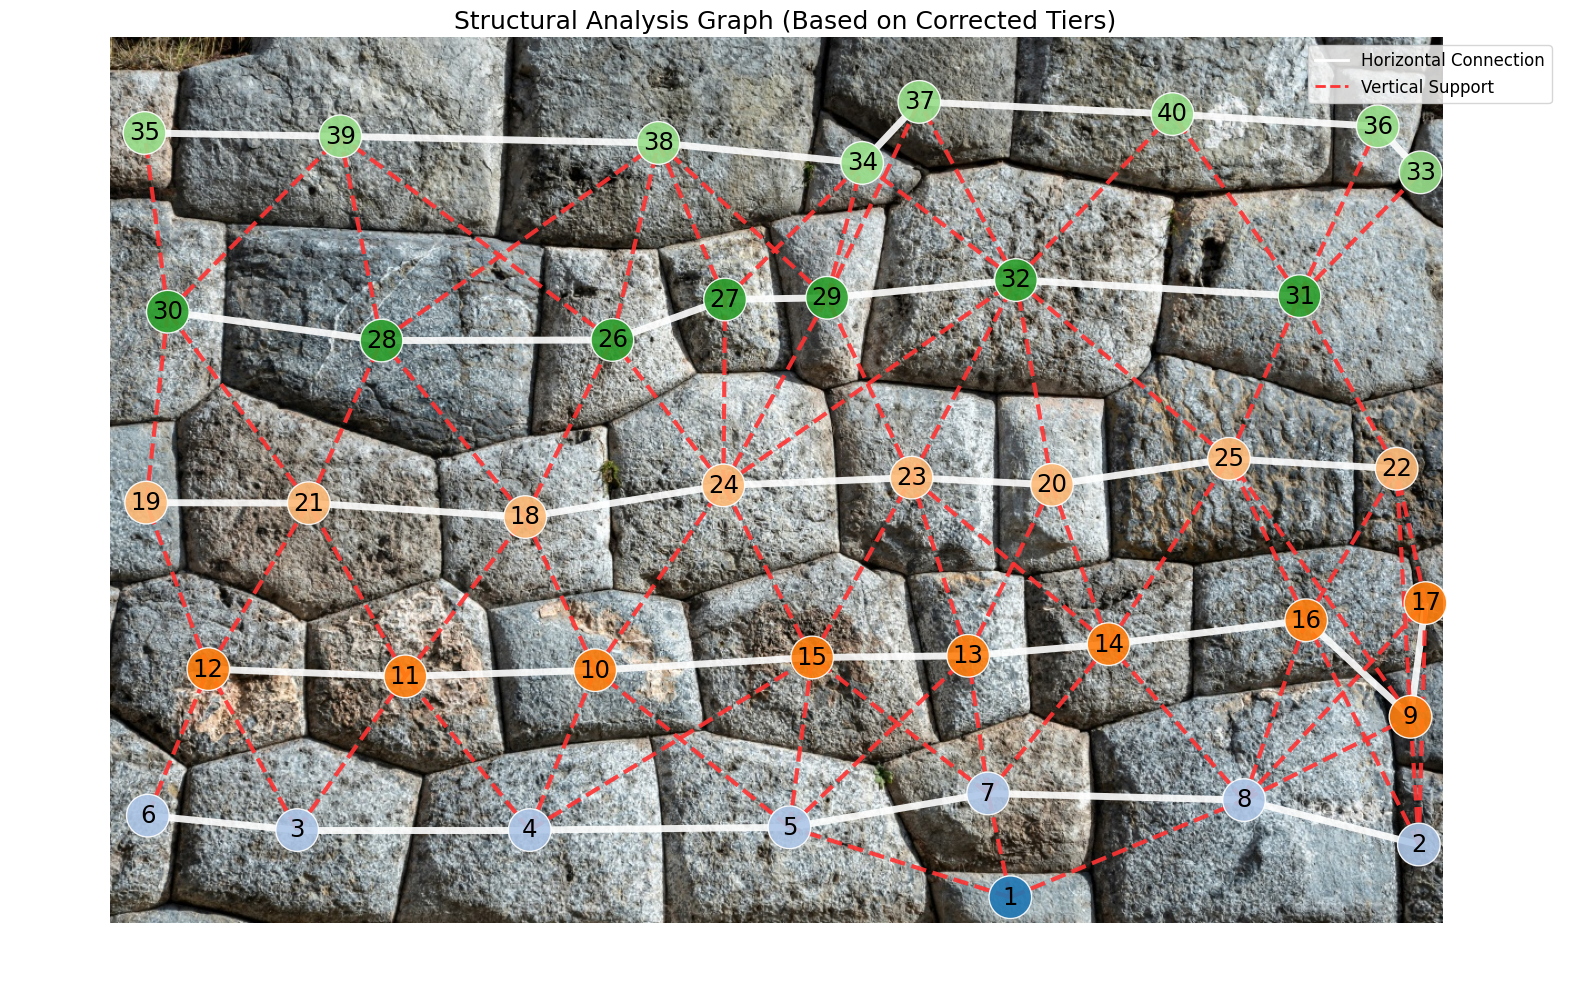

解析結果を structural_analysis_result.csv に保存しました。
            解析サマリー         
画像: images/test_ishigaki_resized.jpg
総石数: 40
構造石の数: 14
■ 総段数 : 6 段
----------------------------------------
Tier  6 (8 stones): 35 -> 39 -> 38 -> 34 -> 37 -> 40 -> 36 -> 33
Tier  5 (7 stones): 30 -> 28 -> 26 -> 27 -> 29 -> 32 -> 31
Tier  4 (8 stones): 19 -> 21 -> 18 -> 24 -> 23 -> 20 -> 25 -> 22
Tier  3 (9 stones): 12 -> 11 -> 10 -> 15 -> 13 -> 14 -> 16 -> 9 -> 17
Tier  2 (7 stones): 6 -> 3 -> 4 -> 5 -> 7 -> 8 -> 2
Tier  1 (1 stones): 1



In [ ]:
# ==========================================
#       フェーズ2 実行ブロック
# ==========================================
if __name__ == "__main__":
    # 前提: フェーズ1が完了し、'df' と 'current_masks' が存在すること
    if 'df' in locals() and 'current_masks' in locals() and not df.empty:
        
        # 1. 構造解析（既存のTier情報を信頼してグラフ構築）
        # dilate_px=20〜40 くらいに増やすと、石同士が離れていても「隣」と判定されやすくなります
        df_final, G_tier = analyze_structure_from_existing_tiers(df, current_masks, dilate_px=50)
        
        # 2. 結果の可視化
        img_path = "images/DJI_0471_resized.JPG" 
        if os.path.exists(img_path):
            image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            visualize_bottom_up(image_rgb, df_final, G_tier, font_size=16)
            
            # CSV保存
            df_final.to_csv("structural_analysis_result.csv", index=False)
            print("解析結果を structural_analysis_result.csv に保存しました。")
        
        # 3. サマリー
        print_analysis_summary(df_final)

    else:
        print("エラー: フェーズ1のデータ(df, current_masks)が見つかりません。")

In [38]:
# --- 【必要に応じて】石の詳細検索実行ブロック ---

if __name__ == "__main__":
    # 解析済みデータが存在するかチェック
    target_df = None
    target_G = None
    
    # フェーズ2（構造解析）の結果を優先
    if 'df_final' in locals() and df_final is not None:
        target_df = df_final
        if 'G_tier' in locals():
            target_G = G_tier
    # なければフェーズ1の結果を使用
    elif 'df' in locals() and df is not None:
        target_df = df
        print("※警告: フェーズ2（Tier推定）が未完了のため、隣接情報は表示されません。")
    
    # 実行
    if target_df is not None and 'current_masks' in locals() and current_masks is not None:
        print("\n【石詳細検索モード】")
        
        while True:
            print("-" * 40)
            user_input = input("詳細を見たい石の番号(Stone_ID)を入力 (終了は 'q' または Enter): ").strip()
            
            # 終了判定
            if not user_input or user_input.lower() == 'q':
                print("検索を終了します。")
                break
            
            try:
                target_id = int(user_input)
                # ここで G=target_G を渡すのがポイント
                search_stone_info(target_id, target_df, current_masks, G=target_G)
                
            except ValueError:
                print("エラー: 数値を入力してください。")
            except Exception as e:
                print(f"予期せぬエラーが発生しました: {e}")
                
    else:
        print("エラー: 解析データが見つかりません。先にフェーズ1またはフェーズ2を実行してください。")


【石詳細検索モード】
----------------------------------------
検索を終了します。
